In [ ]:
import pandas as pd
import numpy as np

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample

import json
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load data

In [ ]:


# Function to read JSON files and extract data
def read_accuracies(base_dir):
    data = []
    
    # Walk through directories
    for dirname in os.listdir(base_dir):
        if dirname.startswith('fold3_cell_type_'):
            # Extract batch size from directory name
            batch_size = int(dirname.split('_')[-1])
            
            # Read JSON file
            json_path = os.path.join(base_dir, dirname, 'cell_type_accuracies.json')
            if os.path.exists(json_path):
                with open(json_path, 'r') as f:
                    accuracies = json.load(f)
                    
                # Create entries for each cell type
                for cell_type, accuracy in accuracies.items():
                    if cell_type in ["ENT DL", "NA"]:
                        continue

                    data.append({
                        'batch_size': batch_size,
                        'cell_type': cell_type,
                        'accuracy': accuracy
                    })
    
    return pd.DataFrame(data)



In [3]:
df = read_accuracies('../../outputs/')
df.head()

,batch_size,cell_type,accuracy
0,4,Car3,0.463369
1,4,L2/3 IT,0.418146
2,4,L4/5 IT,0.462981
3,4,L5 ET,0.494938
4,4,L5 IT,0.455471


In [ ]:

def plot_accuracy_vs_parameters(df, parameters, accuracy_col='accuracy'):
    """
    Plots accuracy as a function of a set of parameters.
    
    Args:
        df (pd.DataFrame): The DataFrame containing the data.
        parameters (list): A list of column names to plot against accuracy.
        accuracy_col (str): The name of the accuracy column. Default is 'accuracy'.
    """
    for param in parameters:
        plt.figure(figsize=(5, 3))
        sns.lineplot(data=df, x=param, y=accuracy_col, marker='o', ci=None)
        plt.title(f'Accuracy vs {param}')
        plt.xlabel(param)
        plt.ylabel('Accuracy')
        plt.show()

import itertools

def plot_2way_combinations(df, parameters, accuracy_col='accuracy'):
    """
    Plots 2-way combinations of parameters with accuracy as color.
    
    Args:
        df (pd.DataFrame): The DataFrame containing the data.
        parameters (list): A list of column names to plot.
        accuracy_col (str): The name of the accuracy column. Default is 'accuracy'.
    """
    combinations = list(itertools.combinations(parameters, 2))
    
    for (param1, param2) in combinations:
        plt.figure(figsize=(5, 3))
        scatter = plt.scatter(data=df, x=param1, y=param2, c=accuracy_col, cmap='viridis')
        plt.colorbar(scatter, label='Accuracy')
        plt.title(f'{param1} vs {param2} with Accuracy as Color')
        plt.xlabel(param1)
        plt.ylabel(param2)
        plt.show()

plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

api = wandb.Api()

# Project is specified by <entity/project-name>
runs = api.runs("zadorlab/spatial-transformer-sweep")

summary_list, config_list, name_list = [], [], []
for run in runs: 
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files 
    run_info = run.summary._json_dict.copy()

    run_info['state'] = run.state  # 'finished', 'running', 'crashed', etc.
    summary_list.append(run_info)


    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k,v in run.config.items()
          if not k.startswith('_')})

    # .name is the human-readable name of the run.
    name_list.append(run.name)

summary_df = pd.json_normalize(summary_list)

# Flatten the 'config' column
config_df = pd.json_normalize(config_list)

summary_df['accuracy'] = 100 * summary_df['eval/accuracy']

# Concatenate the flattened DataFrames along with the 'name' column
runs_df = pd.concat([summary_df, config_df], axis=1)



runs = api.runs("zadorlab/benchmarks-sweep")

summary_list, config_list, name_list = [], [], []
for run in runs: 
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files 
    run_info = run.summary._json_dict.copy()

    run_info['state'] = run.state  # 'finished', 'running', 'crashed', etc.
    summary_list.append(run_info)


    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k,v in run.config.items()
          if not k.startswith('_')})

    # .name is the human-readable name of the run.
    name_list.append(run.name)

summary_df = pd.json_normalize(summary_list)

# Flatten the 'config' column
config_df = pd.json_normalize(config_list)

# Concatenate the flattened DataFrames along with the 'name' column
benchmark_runs_df = pd.concat([summary_df, config_df], axis=1)
benchmark_runs_df.head(15)


,_runtime,_step,_timestamp,_wandb.runtime,bulk_expression_test_accuracy,bulk_expression_test_f1_0,bulk_expression_test_f1_100,bulk_expression_test_f1_103,bulk_expression_test_f1_106,bulk_expression_test_f1_110,...,resample_adata,debug_args.on_adata,debug_args.resample_adata,data.sampling_strategy,data.sampling.group_within_keys,data.sampling.hex_scaling,data.sampling.max_radius_expansions,data.sampling.reflect_points,data.sampling.strategy,data.sampling.use_train_hex_grid_on_eval
0,4428.714756,2.0,1.732252e+09,63650.0,0.011601,0.0,0.014877,0.007900,0.003986,0.009327,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,711.676399,2.0,1.732296e+09,711.0,0.090336,NaN,0.000000,0.000000,0.000000,0.291508,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,683.488715,2.0,1.732296e+09,683.0,0.106843,NaN,0.000000,0.000000,0.000000,0.447689,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,764.160960,2.0,1.732296e+09,764.0,0.092587,NaN,0.000000,0.000000,0.000000,0.332713,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,964.289842,1.0,1.732296e+09,964.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,943.517417,2.0,1.732296e+09,943.0,0.047719,NaN,0.000000,0.000000,0.000000,0.116686,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## now plot

[Text(0, 0.0, '0.0'), Text(0, 0.2, '0.2'), Text(0, 0.4, '0.4'), Text(0, 0.6000000000000001, '0.6'), Text(0, 0.8, '0.8'), Text(0, 1.0, '1.0')]


/tmp/ipykernel_3471878/1656925660.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(100*float(label.get_text()))}' for label in ax.get_yticklabels()])


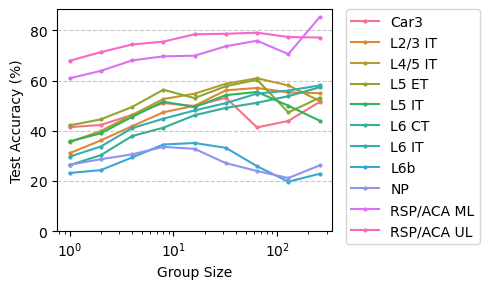

In [4]:
# sns.set_style("whitegrid")
plt.figure(figsize=(5, 3))

sns.lineplot(data=df, 
            x='batch_size', 
            y='accuracy', 
            hue='cell_type',
            marker='.',
            markeredgecolor='none')

# Customize the plot
plt.xlabel('Group Size')
plt.ylabel('Test Accuracy (%)')

# Rotate x-axis labels if needed
# plt.xticks(rotation=45)

# Move legend to a better position
plt.legend(loc='lower right')
plt.ylim(0, plt.ylim()[1])


# Relabel the y-axis ticks to multiply the labels by 100
ax = plt.gca()
print(ax.get_yticklabels())
# current_labels = ax.get_yticks()
# ax.set_yticklabels([f'{int(label * 100)}' for label in current_labels])
ax.set_yticklabels([f'{int(100*float(label.get_text()))}' for label in ax.get_yticklabels()])
# ax.grid(None)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# plt.tight_layout()


# Rotate legend labels if needed
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

# Adjust layout to prevent legend cutoff WITHOUT using tight_layout
plt.subplots_adjust(right=0.75)
plt.tight_layout()
# # Save plot with a better filename indicating the context
# plt.savefig('fig_1g_cell_type_accuracy_by_batch_size.png', bbox_inches='tight', dpi=300)
# plt.savefig('fig_1g_cell_type_accuracy_by_batch_size.pdf', bbox_inches='tight')
plt.xscale('log')
plt.tight_layout()
# plt.savefig(f"fig_1g_cell_type_accuracy_by_batch_size_log.png", dpi=300)
# plt.savefig(f"fig_1g_cell_type_accuracy_by_batch_size_log.pdf")
# plt.show()


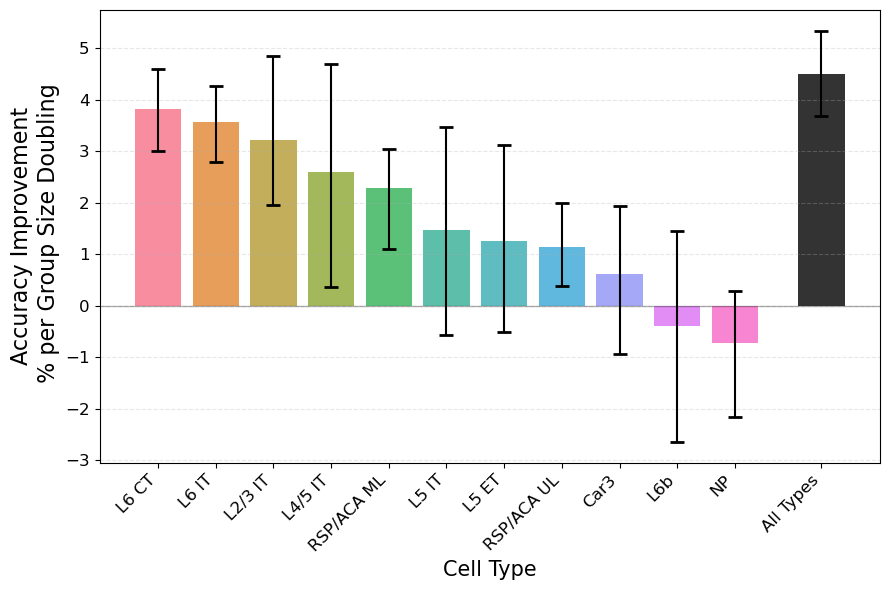


Slope Analysis Summary:
L6 CT: 3.8212 (95% CI: [3.0026, 4.5878])
L6 IT: 3.5717 (95% CI: [2.7856, 4.2618])
L2/3 IT: 3.2099 (95% CI: [1.9632, 4.8501])
L4/5 IT: 2.5949 (95% CI: [0.3696, 4.6974])
RSP/ACA ML: 2.2861 (95% CI: [1.0915, 3.0431])
L5 IT: 1.4776 (95% CI: [-0.5789, 3.4770])
L5 ET: 1.2609 (95% CI: [-0.5056, 3.1235])
RSP/ACA UL: 1.1290 (95% CI: [0.3721, 1.9907])
Car3: 0.6209 (95% CI: [-0.9346, 1.9376])
L6b: -0.3894 (95% CI: [-2.6504, 1.4521])
NP: -0.7210 (95% CI: [-2.1711, 0.2821])

All Types (Aggregate): 4.4899 (95% CI: [3.6875, 5.3405])


In [16]:


accuracy_col = 'test/accuracy'


# Function to calculate slope with bootstrap confidence intervals
def calculate_slope_with_ci(x, y, n_bootstrap=1000, confidence=0.95):
    """
    Calculate slope and confidence interval using bootstrap
    """
    # Fit original model
    X = x.values.reshape(-1, 1)
    Y = y.values * 100
    model = LinearRegression()
    model.fit(X, Y)
    slope = model.coef_[0]
    
    # Bootstrap for confidence interval
    slopes = []
    n_samples = len(x)
    
    for _ in range(n_bootstrap):
        # Resample indices
        indices = resample(range(n_samples), n_samples=n_samples)
        X_boot = X[indices]
        Y_boot = Y[indices]
        
        # Fit model on bootstrap sample
        model_boot = LinearRegression()
        model_boot.fit(X_boot, Y_boot)
        slopes.append(model_boot.coef_[0])
    
    # Calculate confidence interval
    alpha = 1 - confidence
    lower = np.percentile(slopes, 100 * alpha/2)
    upper = np.percentile(slopes, 100 * (1 - alpha/2))
    
    return slope, lower, upper

# Calculate log2 of batch sizes
df['log2_batch_size'] = np.log2(df['batch_size'])

# Calculate slopes for each cell type
results = []
cell_types = df['cell_type'].unique()

for cell_type in cell_types:
    # Filter data for this cell type
    cell_data = df[df['cell_type'] == cell_type].copy()
    
    # Sort by batch size
    cell_data = cell_data.sort_values('log2_batch_size')
    
    # Calculate slope with confidence interval
    slope, ci_lower, ci_upper = calculate_slope_with_ci(
        cell_data['log2_batch_size'], 
        cell_data['accuracy']
    )
    
    results.append({
        'cell_type': cell_type,
        'slope': slope,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'error_lower': slope - ci_lower,
        'error_upper': ci_upper - slope
    })

# Calculate aggregate slope from separate filtered data
# Filter runs_df for "All Types" data
tags = [[f"fold{f}_animal_name"] for f in range(4)]
filter_ = runs_df['wandb.tags'].isin(tags)
all_types_data = runs_df[filter_].copy()
idx = ~all_types_data[accuracy_col].isna()
all_types_data = all_types_data[idx]

# Rename columns to match expected format if needed
all_types_data['batch_size'] = all_types_data['data.group_size']
all_types_data['accuracy'] = all_types_data[accuracy_col]
all_types_data['log2_batch_size'] = np.log2(all_types_data['batch_size'])

# Sort by batch size
all_types_data = all_types_data.sort_values('log2_batch_size')

# Calculate slope with confidence interval
all_slope, all_ci_lower, all_ci_upper = calculate_slope_with_ci(
    all_types_data['log2_batch_size'], 
    all_types_data['accuracy']
)

results.append({
    'cell_type': 'All Types',
    'slope': all_slope,
    'ci_lower': all_ci_lower,
    'ci_upper': all_ci_upper,
    'error_lower': all_slope - all_ci_lower,
    'error_upper': all_ci_upper - all_slope
})

# Convert to DataFrame
slope_df = pd.DataFrame(results)

# Create the plot
plt.figure(figsize=(9, 6))

# Separate "All Types" from individual cell types
all_types_row = slope_df[slope_df['cell_type'] == 'All Types']
individual_types = slope_df[slope_df['cell_type'] != 'All Types'].sort_values('slope', ascending=False)

# Combine with "All Types" at the end
slope_df = pd.concat([individual_types, all_types_row])

# Create x positions with a gap before "All Types"
x_pos = []
for i in range(len(individual_types)):
    x_pos.append(i)
# Add gap of 0.5 units before "All Types"
x_pos.append(len(individual_types) + 0.5)
x_pos = np.array(x_pos)

# Create colors - use colorful palette for individual types, black for "All Types"
colors = sns.color_palette("husl", len(individual_types))
colors.append('black')  # Black for "All Types"

# Plot bars
bars = plt.bar(x_pos, slope_df['slope'], color=colors, alpha=0.8)

# Add error bars
plt.errorbar(x_pos, slope_df['slope'], 
             yerr=[slope_df['error_lower'], slope_df['error_upper']], 
             fmt='none', color='black', capsize=5, capthick=2)

# Customize plot
plt.xlabel('Cell Type', fontsize=15)
plt.ylabel('Accuracy Improvement\n % per Group Size Doubling', fontsize=16)
# plt.title('Rate of Accuracy Improvement with Increasing Group Size', fontsize=14)

# Set x-axis labels
plt.xticks(x_pos, slope_df['cell_type'], rotation=45, ha='right')

# Add grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)

# Adjust layout
plt.tight_layout()
# Save the plot
plt.savefig('accuracy_improvement_per_doubling.png', dpi=300, bbox_inches='tight')
plt.savefig('accuracy_improvement_per_doubling.pdf', bbox_inches='tight')

plt.show()

# Print summary statistics
print("\nSlope Analysis Summary:")
print("=" * 50)
for _, row in slope_df.iterrows():
    if row['cell_type'] == 'All Types':
        print(f"\n{row['cell_type']} (Aggregate): {row['slope']:.4f} (95% CI: [{row['ci_lower']:.4f}, {row['ci_upper']:.4f}])")
    else:
        print(f"{row['cell_type']}: {row['slope']:.4f} (95% CI: [{row['ci_lower']:.4f}, {row['ci_upper']:.4f}])")